# 1. Import Libraries

In [1]:
from langchain.tools import tool
from langgraph.graph import StateGraph, END
from typing import TypedDict

# 2. Define State

In [2]:
class AgentState(TypedDict):
    input: str
    output: str

# 3. Create Tool

In [3]:
import re
from langchain.tools import tool

@tool
def calculator(expression: str) -> str:
    """Evaluate mathematical expressions"""

    try:
        # Extract only math part
        cleaned = re.sub(r"[^0-9+\-*/(). ]","", expression)

        return str(eval(cleaned))
    except Exception as e:
        return f"Error: {e}"
        
    

## Step 4: LLM Setup

In [4]:
from langchain_ollama import ChatOllama

In [5]:
llm = ChatOllama(
    model = "llama3.2",
    temperature = 0
)

## Step 5: LLM Node (Reasoning)

In [6]:
def reason_node(state: AgentState):
    response = llm.invoke(state["input"])
    return {"output": response.content}
    

## Step 6: Tool Node (Action)

In [7]:
def tool_node(state: AgentState):
    result = calculator.invoke(state["input"])
    return {"output":result}

## step 7 : Conditional Routing


In [8]:
def should_use_tool(state: AgentState):
    if any(char.isdigit() for char in state["input"]):
        return "tool"
    return "end"

## step 8: Build Graph

In [9]:
builder = StateGraph(AgentState)

builder.add_node("reason", reason_node)
builder.add_node("tool", tool_node)

builder.set_entry_point("reason")

builder.add_conditional_edges(
    "reason",
    should_use_tool,
    {
        "tool": "tool",
        "end": END
    }
)

builder.add_edge("tool", END)

graph = builder.compile()

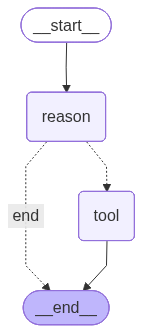

In [11]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Step 9 : Run Agent

In [23]:
result= graph.invoke({"input":"What is 25 * 4 + 10?"})
print(result['output'])

110
